# Deep Learning Assignment 3 - Part 1

Student 1: Merry Shalabi 324007202

Student 2: Samih Warwar 324888155

In [12]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
file_path = '/content/drive/MyDrive/Deep_learning/Songs.csv'
import pandas as pd

data = pd.read_csv(file_path)

data.head()

,Artist,Title,Lyrics
0,Taylor Swift,cardigan,"Vintage tee, brand new phone\nHigh heels on co..."
1,Taylor Swift,exile,"I can see you standing, honey\nWith his arms a..."
2,Taylor Swift,Lover,We could leave the Christmas lights up 'til Ja...
3,Taylor Swift,the 1,"I'm doing good, I'm on some new shit\nBeen say..."
4,Taylor Swift,Look What You Made Me Do,I don't like your little games\nDon't like you...


analyzes song lyrics data by counting songs per artist, determining the dataset size, calculating the number of songs, computing the average number of words and characters per song, and visualizing the top 3 most common words ('I', 'you', 'the').

Artist
Taylor Swift          50
David Bowie           50
Billy Joel            50
Eric Clapton          50
Billie Eilish         50
Leonard Cohen         50
Bruce Springsteen     40
The Beatles           35
Ray LaMontagne        30
Elton John            30
Queen                 30
Frank Sinatra         30
John Denver           30
Bryan Adams           30
​twenty one pilots    30
Nat King Cole         30
Lana Del Rey          30
Vance Joy             30
George Michael        30
Bob Dylan             20
Ed Sheeran            20
Name: count, dtype: int64
The dataset contains 745 songs and 3 columns.
Average number of characters per song: 1403.34
Average number of words per song: 276.26
Top 3 most used words: [('i', 10043), ('you', 8350), ('the', 8148)]


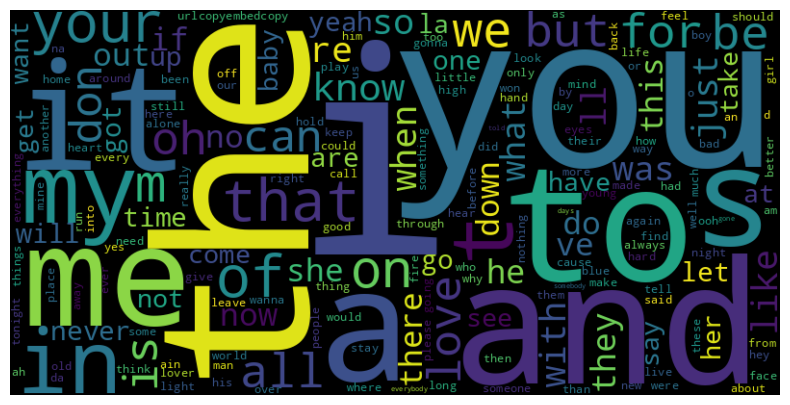

In [14]:
from collections import Counter
import re
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# count the number of songs for each artist
artist_song_count = data['Artist'].value_counts()

# print the artist names and their corresponding song counts
print(artist_song_count)

# print the shape of the dataset (number of songs and number of columns)
print(f"The dataset contains {data.shape[0]} songs and {data.shape[1]} columns.")

# calculate the number of characters and words for each song
data['num_characters'] = data['Lyrics'].apply(lambda x: len(x))
data['num_words'] = data['Lyrics'].apply(lambda x: len(x.split()))

# calculate the average length of a song in characters and words
average_characters = data['num_characters'].mean()
average_words = data['num_words'].mean()

print(f"Average number of characters per song: {average_characters:.2f}")
print(f"Average number of words per song: {average_words:.2f}")

# combine all the lyrics into one large text
all_lyrics = ' '.join(data['Lyrics'].dropna())

# remove non-alphanumeric characters and split into words
words = re.findall(r'\w+', all_lyrics.lower())

# count the frequency of each word
word_counts = Counter(words)

# get the top 3 most common words
top_3_words = word_counts.most_common(3)

print("Top 3 most used words:", top_3_words)

# generate the word cloud
wordcloud = WordCloud(width=800, height=400).generate_from_frequencies(word_counts)

# plot the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()





preprocessing songs lyrics data by cleaning and normalizing text, converting characters to numerical representations, and preparing input sequences for a character language model

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import re
import unicodedata

corpus = " ".join(data['Lyrics'])

def clean_text(text):
    text = unicodedata.normalize("NFKD", text).encode("ascii", "ignore").decode("utf-8")
    text = re.sub(r"[^\w\s']", '', text)
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    text = re.sub(r'(.)\1{3,}', r'\1\1', text)
    return text.lower()


corpus = " ".join(data['Lyrics'].dropna().apply(clean_text))

# convert to lowercase
corpus = corpus.lower()
chars = sorted(list(set(corpus)))
char_to_int = {c: i for i, c in enumerate(chars)}
int_to_char = {i: c for i, c in enumerate(chars)}
encoded_corpus = [char_to_int[c] for c in corpus]
seq_length = 62
X = []
y = []
for i in range(len(encoded_corpus) - seq_length):
    X.append(encoded_corpus[i:i+seq_length])
    y.append(encoded_corpus[i+seq_length])
X = torch.tensor(X, dtype=torch.long)
y = torch.tensor(y, dtype=torch.long)


model definition:

In [17]:
import torch
import torch.nn as nn

class LyricsLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=1, embedding_dim=64):
        super(LyricsLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.embeddings = nn.Embedding(input_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_size, num_layers, batch_first=True)
        # batch normalization to stabilize learning
        self.bn = nn.BatchNorm1d(hidden_size)
        # dropout to prevent overfitting
        self.dropout = nn.Dropout(p=0.3)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x, hidden):
        embeds = self.embeddings(x)
        out, hidden = self.lstm(embeds, hidden)
        out = self.bn(out[:, -1, :])
        out = self.dropout(out)
        out = self.fc(out)
        return out, hidden

training :

Epoch 1, Loss: 1.3818636031482143
Epoch 2, Loss: 1.1050801725939408
Epoch 3, Loss: 1.024275609677695
Epoch 4, Loss: 0.9783488095709812
Epoch 5, Loss: 0.9476588772894798
Epoch 6, Loss: 0.9243946331676235
Epoch 7, Loss: 0.9074088173380499
Epoch 8, Loss: 0.8942670375689298
Epoch 9, Loss: 0.8810456898668263
Epoch 10, Loss: 0.8714047312084369
Epoch 11, Loss: 0.8626306033795718
Epoch 12, Loss: 0.8570292440855333
Epoch 13, Loss: 0.8499239426138021
Epoch 14, Loss: 0.8439011360826815
Epoch 15, Loss: 0.8388699261587745
Epoch 16, Loss: 0.8354652759157196
Epoch 17, Loss: 0.8307273573779528
Epoch 18, Loss: 0.8272780301911723
Epoch 19, Loss: 0.8230419237904294
Epoch 20, Loss: 0.8200132760916466
Epoch 21, Loss: 0.8182352678597058
Epoch 22, Loss: 0.814941071532066
Epoch 23, Loss: 0.8128335630375654
Epoch 24, Loss: 0.8104055534987704
Epoch 25, Loss: 0.8076701384170512
Epoch 26, Loss: 0.8084324743373513
Epoch 27, Loss: 0.8054605170011123
Epoch 28, Loss: 0.8033928515181594
Epoch 29, Loss: 0.8011951067400

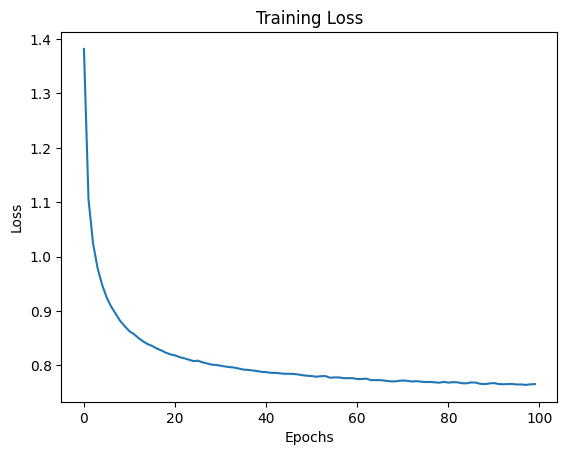

In [18]:
# initialize model, loss, and optimizer
model = LyricsLSTM(input_size=len(chars), hidden_size=128 ,num_layers=2, output_size=len(chars))
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# move model and data to the same device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
X, y = X.to(device), y.to(device)

# training loop with batch processing
batch_size = 64
losses = []

for epoch in range(100):
    model.train()
    epoch_loss = 0

    for i in range(0, len(X), batch_size):
        # get a batch of data
        X_batch = X[i:i+batch_size].to(device)
        y_batch = y[i:i+batch_size].to(device)

        # initialize hidden state for each batch
        hidden = (torch.zeros(model.num_layers, X_batch.size(0), model.hidden_size).to(device),
                  torch.zeros(model.num_layers, X_batch.size(0), model.hidden_size).to(device))

        # forward pass
        optimizer.zero_grad()
        output, hidden = model(X_batch, hidden)

        # compute loss
        loss = criterion(output, y_batch)
        epoch_loss += loss.item()

        # backward pass and optimization
        loss.backward()
        # clip gradients to avoid exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

    # print average loss for the epoch
    avg_loss = epoch_loss / (len(X) // batch_size)
    losses.append(avg_loss)
    print(f'Epoch {epoch+1}, Loss: {avg_loss}')

# plot training loss
plt.plot(range(100), losses)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()

this function generates text using the trained LSTM model with greedy, temperature-based, top-k, or top-p sampling strategies.

In [90]:
import torch.nn.functional as F

def LyricsGenerator(model, starting_string, char_count=200, strategy="greedy", temperature=0.8, top_k=5, top_p=0.8):
    model.eval()
    device = next(model.parameters()).device

    if not starting_string.strip():
        starting_string = np.random.choice(list(char_to_int.keys()))

    cleaned_start = "".join([char for char in starting_string.lower() if char in char_to_int])
    if not cleaned_start:
        cleaned_start = np.random.choice(list(char_to_int.keys()))

    input_indices = [char_to_int.get(ch, 1) for ch in cleaned_start]
    input_tensor = torch.tensor(input_indices, dtype=torch.long).unsqueeze(0).to(device)

    hidden = (torch.zeros(model.num_layers, 1, model.hidden_size).to(device),
              torch.zeros(model.num_layers, 1, model.hidden_size).to(device))

    generated_text = starting_string

    for _ in range(char_count):
        with torch.no_grad():
            if input_tensor.size(1) == 0:
                input_tensor = torch.tensor([[char_to_int[np.random.choice(list(char_to_int.keys()))]]], dtype=torch.long).to(device)

            outputs, hidden = model(input_tensor, hidden)
            last_logits = outputs

            # apply temperature scaling
            scaled_logits = last_logits / temperature
            probs = F.softmax(scaled_logits, dim=-1)

        if strategy == "greedy":
            next_token = torch.argmax(probs, dim=-1).item()

        elif strategy == "top-k":
            topk_probs, topk_indices = torch.topk(probs, k=top_k)
            topk_probs = topk_probs / topk_probs.sum()
            next_token = np.random.choice(topk_indices.cpu().numpy().flatten(), p=topk_probs.cpu().numpy().flatten())

        elif strategy == "top-p":
            sorted_probs, sorted_indices = torch.sort(probs, descending=True)
            cumulative_probs = torch.cumsum(sorted_probs, dim=-1)
            cutoff_index = torch.where(cumulative_probs > top_p)[0][0].item() if torch.where(cumulative_probs > top_p)[0].numel() > 0 else len(sorted_probs) - 1

            filtered_probs = sorted_probs[:cutoff_index+1]
            filtered_indices = sorted_indices[:cutoff_index+1]
            filtered_probs = filtered_probs / filtered_probs.sum()

            next_token = np.random.choice(filtered_indices.cpu().numpy().flatten(), p=filtered_probs.cpu().numpy().flatten())

        else:
            raise ValueError("Invalid strategy. Use 'greedy', 'top-k', or 'top-p'.")

        next_char = int_to_char.get(next_token, ' ')
        generated_text += next_char
        input_tensor = torch.tensor([[next_token]], dtype=torch.long).to(device)

    return generated_text

The model did not generate meaningful song lyrics, and most of the text did not make sense. Top-K Sampling worked better than Greedy and Top-P, as it kept some structure while adding variety. Greedy was too repetitive, and Top-P was too random.

In [93]:
# Define starting strings
starting_strings = [
    ("it's not a silly little moment ", "Song 1"),
    ("Somebody once told me the world is gonna roll me ", "Song 2"),
    ("", "Song 3")
]

# Generate lyrics for each song
for start_text, song_name in starting_strings:
    print(f"\n\nGenerating {song_name} Lyrics (Starting: '{start_text}')\n")

    for strategy in ["greedy", "top-k", "top-p"]:
        print(f"\nStrategy: {strategy} : \n")

        generated_lyrics = LyricsGenerator(
            model=model,
            starting_string=start_text,
            char_count=300,
            strategy=strategy,
            temperature=0.8,
            top_k=5,
            top_p=0.8
        )

        print(generated_lyrics)




Generating Song 1 Lyrics (Starting: 'it's not a silly little moment ')


Strategy: greedy : 

it's not a silly little moment kiss now tear you to see the company love and i want to help here somethin' end man loose has there i don't wanna love there's nothing taste me a children of love in the man east he's loved in the rain star it's long hold or emptyself now the sea i'm still and how the rain lies don't have to change 

Strategy: top-k : 

it's not a silly little moment kan o you wanted back to so tears and things the' spection i loved you mother's right i tell her old flowers what'cly that that hounder let is heard and let's should dance fat the invigls i'm road of life that is a little hard i'm spair earth honey their soldier now and me if the hold is a prae love

Strategy: top-p : 

it's not a silly little moment grown tears syck at and too embedshare urlcopyembedcopy i will not a little ecton the rain close day is night that he's how many if thrives ran of your eyes love's tar

In [88]:
print("Model Summary \n")
print(model)

print(f"\nTotal Trainable Parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}\n")


Model Summary 

LyricsLSTM(
  (word_embeddings): Embedding(28, 64)
  (lstm): LSTM(64, 128, num_layers=2, batch_first=True)
  (bn): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=28, bias=True)
)

Total Trainable Parameters: 237084

